# Pure-space x1 radial spectral diagnostic: July 2024 generalized Cauchy alpha-beta grid

This notebook focuses only on July 2024 and compares a dense generalized Cauchy grid against the Matérn smooth=0.3 nugget-zero baseline.

- x1 full-grid fits only
- no directional spectra
- selected calendar days: 2, 4, 7, 13, and 24, giving 5 days x 8 GEMS daytime slices = 40 fits per model
- existing 4x4 ClusterB2 Vecchia geometry: max-min cluster-center ordering, condition on nearest 2 previous blocks
- nugget fixed 0 for all candidates
- baseline: Matérn smooth=0.3 nugget0
- generalized Cauchy grid: alpha in [0.75, 0.8, 0.85, 0.9, 0.95, 1.0] crossed with beta in [1.0, 0.5]
- average radial plots include slice-to-slice variability clouds for data spectra, expected periodograms, and I/E[I] ratios
- outputs are saved under a 2024-specific prefix: plot, all-frequency ratio table, selected-frequency ratio table, and band summaries


In [1]:
import gc
import importlib
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from scipy.special import gamma, kv

LOCAL_SRC = '/Users/joonwonlee/Documents/GEMS_TCO-1/src'
AMAREL_SRC = '/home/jl2815/tco'
SRC = AMAREL_SRC if Path(AMAREL_SRC).exists() else LOCAL_SRC
if SRC not in sys.path:
    sys.path.insert(0, SRC)

from GEMS_TCO import configuration as config
from GEMS_TCO.data_loader import load_data_dynamic_processed
import GEMS_TCO.kernels_space_base_engine_052126 as kernels_space_base_engine_052126
import GEMS_TCO.kernels_space_aniso_cluster_060326 as kernels_space_aniso_cluster_060326
import GEMS_TCO.kernels_space_aniso_cauchy_cluster_060326 as kernels_space_aniso_cauchy_cluster_060326

importlib.reload(kernels_space_base_engine_052126)
importlib.reload(kernels_space_aniso_cluster_060326)
importlib.reload(kernels_space_aniso_cauchy_cluster_060326)

from GEMS_TCO.kernels_space_aniso_cluster_060326 import (
    ClusterSpaceAnisoTrendVecchiaFit,
    ClusterSpaceAnisoNoNuggetTrendVecchiaFit,
)
from GEMS_TCO.kernels_space_aniso_cauchy_cluster_060326 import (
    ClusterSpaceAnisoCauchyFixedBetaTrendVecchiaFit,
    ClusterSpaceAnisoCauchyFixedBetaNoNuggetTrendVecchiaFit,
    cauchy_phi_init_from_natural,
)

DEVICE = torch.device('cpu')
DTYPE = torch.float64
ROUND_DECIMALS = 5

pd.set_option('display.max_columns', 180)
pd.set_option('display.width', 260)
print('SRC:', SRC)
print('device:', DEVICE)


SRC: /Users/joonwonlee/Documents/GEMS_TCO-1/src
device: cpu


In [2]:
# Experiment config
MONTH = 7
DEFAULT_SELECTED_DAY_NUMBERS = [2, 4, 7, 13, 24]
SLICES_PER_DAY = 8
LAT_RANGE = [-3, 2]
LON_RANGE = [121, 131]
SMOOTH = 0.3
RESOLUTION_STRIDE = 1
MEAN_DESIGN = 'lat'

CLUSTER_SPEC = {
    'block_shape': (4, 4),
    'n_neighbor_blocks': 2,
    'target_chunk_size': 128,
    'min_target_points': 1,
}

GC_ALPHA_GRID_2024 = [0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 1.0]
GC_BETA_GRID_2024 = [0.3, 0.5, 1.0]

YEAR_CONFIGS = {
    '2024': {
        'selected_days': DEFAULT_SELECTED_DAY_NUMBERS,
        'matern_modes': ['nugget0'],
        'gc_specs': [
            {'alpha': alpha, 'betas': GC_BETA_GRID_2024, 'nugget_modes': ['nugget0']}
            for alpha in GC_ALPHA_GRID_2024
        ],
    },
}


LBFGS_LR = 1.0
LBFGS_STEPS_FULL = 8
LBFGS_EVAL = 20
LBFGS_HIST = 10
GRAD_TOL = 1e-5

RUN_FULL = True
RUN_SPECTRUM = True
RUN_PLOTS = True
RUN_TABLES = True

PURE_SPACE_DIR = Path('/Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space')
OUT_DIR = PURE_SPACE_DIR / 'log'
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_PREFIX_BASE = 'real_pure_space_spectral_x1_2024_gc_alpha_beta_grid_refine_nugget0_clusterb2_061426'

print('years:', list(YEAR_CONFIGS))
print('selected days default:', DEFAULT_SELECTED_DAY_NUMBERS)
print('GC alpha grid:', GC_ALPHA_GRID_2024)
print('GC beta grid:', GC_BETA_GRID_2024)
print('models per year:', 1 + len(GC_ALPHA_GRID_2024) * len(GC_BETA_GRID_2024))
print('slices per model:', len(DEFAULT_SELECTED_DAY_NUMBERS) * SLICES_PER_DAY)
print('resolution: x1 only')
print('output prefix base:', OUT_PREFIX_BASE)


years: ['2024']
selected days default: [2, 4, 7, 13, 24]
GC alpha grid: [0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9, 1.0]
GC beta grid: [0.3, 0.5, 1.0]
models per year: 25
slices per model: 40
resolution: x1 only
output prefix base: real_pure_space_spectral_x1_2024_gc_alpha_beta_grid_refine_nugget0_clusterb2_061426


In [3]:
def float_id(x):
    return str(float(x)).replace('.', 'p')


def float_label(x):
    return f'{float(x):g}'


def year_prefix(year):
    return f'{OUT_PREFIX_BASE}_{year}'


def matern_variant_name(nugget_mode):
    return f'matern_s03_{nugget_mode}'


def gc_variant_name(alpha, beta, nugget_mode):
    return f'gc_a{float_id(alpha)}_b{float_id(beta)}_{nugget_mode}'


def make_matern_variant(nugget_mode):
    if nugget_mode == 'nugget0':
        return {
            'family': 'matern',
            'label': 'Matern s=0.3 nugget0',
            'nugget_mode': nugget_mode,
            'class': ClusterSpaceAnisoNoNuggetTrendVecchiaFit,
            'model': 'ClusterSpaceAnisoMaternS03NoNugget_4x4_B2_exactloc',
            'kernel': 'cluster_space_aniso_matern_s03_nugget0_4x4_b2_exactloc',
            'smooth': 0.3,
            'p_labels': ['sigmasq', 'range_lat', 'range_lon'],
            'init': {'sigmasq': 13.0, 'range_lat': 0.25, 'range_lon': 0.25},
        }
    if nugget_mode == 'nugget_free':
        return {
            'family': 'matern',
            'label': 'Matern s=0.3 nugget free',
            'nugget_mode': nugget_mode,
            'class': ClusterSpaceAnisoTrendVecchiaFit,
            'model': 'ClusterSpaceAnisoMaternS03NuggetFree_4x4_B2_exactloc',
            'kernel': 'cluster_space_aniso_matern_s03_nuggetfree_4x4_b2_exactloc',
            'smooth': 0.3,
            'p_labels': ['sigmasq', 'range_lat', 'range_lon', 'nugget'],
            'init': {'sigmasq': 13.0, 'range_lat': 0.25, 'range_lon': 0.25, 'nugget': 1.0},
        }
    raise ValueError(f'Unknown nugget mode: {nugget_mode}')


def make_gc_variant(alpha, beta, nugget_mode):
    common_init = cauchy_phi_init_from_natural(sigmasq=13.0, range_lat=0.25, range_lon=0.25, gc_beta=float(beta))
    alpha_label = float_label(alpha)
    beta_label = float_label(beta)
    beta_token = beta_label.replace('.', 'p')
    if nugget_mode == 'nugget0':
        return {
            'family': 'cauchy',
            'label': f'GC a={alpha_label} b={beta_label} nugget0',
            'nugget_mode': nugget_mode,
            'class': ClusterSpaceAnisoCauchyFixedBetaNoNuggetTrendVecchiaFit,
            'model': f'ClusterSpaceAnisoGeneralizedCauchyA{float_id(alpha)}B{beta_token}NoNugget_4x4_B2_exactloc',
            'kernel': f'cluster_space_aniso_gc_a{float_id(alpha)}_b{beta_token}_nugget0_4x4_b2_exactloc',
            'smooth': float(alpha),
            'gc_alpha': float(alpha),
            'gc_beta': float(beta),
            'p_labels': ['phi1', 'phi2', 'phi3'],
            'init': dict(common_init),
        }
    if nugget_mode == 'nugget_free':
        return {
            'family': 'cauchy',
            'label': f'GC a={alpha_label} b={beta_label} nugget free',
            'nugget_mode': nugget_mode,
            'class': ClusterSpaceAnisoCauchyFixedBetaTrendVecchiaFit,
            'model': f'ClusterSpaceAnisoGeneralizedCauchyA{float_id(alpha)}B{beta_token}NuggetFree_4x4_B2_exactloc',
            'kernel': f'cluster_space_aniso_gc_a{float_id(alpha)}_b{beta_token}_nuggetfree_4x4_b2_exactloc',
            'smooth': float(alpha),
            'gc_alpha': float(alpha),
            'gc_beta': float(beta),
            'p_labels': ['phi1', 'phi2', 'phi3', 'nugget'],
            'init': {**common_init, 'nugget': 1.0},
        }
    raise ValueError(f'Unknown nugget mode: {nugget_mode}')


def build_variants_for_year(year):
    cfg = YEAR_CONFIGS[str(year)]
    variants = {}
    for mode in cfg.get('matern_modes', []):
        variants[matern_variant_name(mode)] = make_matern_variant(mode)
    for gc_spec in cfg.get('gc_specs', []):
        alpha = float(gc_spec['alpha'])
        for beta in gc_spec['betas']:
            for mode in gc_spec.get('nugget_modes', ['nugget0']):
                variants[gc_variant_name(alpha, beta, mode)] = make_gc_variant(alpha, float(beta), mode)
    return variants


VARIANTS_BY_YEAR = {year: build_variants_for_year(year) for year in YEAR_CONFIGS}
for year, variants in VARIANTS_BY_YEAR.items():
    print(year, len(variants), list(variants))


2024 25 ['matern_s03_nugget0', 'gc_a0p6_b0p3_nugget0', 'gc_a0p6_b0p5_nugget0', 'gc_a0p6_b1p0_nugget0', 'gc_a0p65_b0p3_nugget0', 'gc_a0p65_b0p5_nugget0', 'gc_a0p65_b1p0_nugget0', 'gc_a0p7_b0p3_nugget0', 'gc_a0p7_b0p5_nugget0', 'gc_a0p7_b1p0_nugget0', 'gc_a0p75_b0p3_nugget0', 'gc_a0p75_b0p5_nugget0', 'gc_a0p75_b1p0_nugget0', 'gc_a0p8_b0p3_nugget0', 'gc_a0p8_b0p5_nugget0', 'gc_a0p8_b1p0_nugget0', 'gc_a0p85_b0p3_nugget0', 'gc_a0p85_b0p5_nugget0', 'gc_a0p85_b1p0_nugget0', 'gc_a0p9_b0p3_nugget0', 'gc_a0p9_b0p5_nugget0', 'gc_a0p9_b1p0_nugget0', 'gc_a1p0_b0p3_nugget0', 'gc_a1p0_b0p5_nugget0', 'gc_a1p0_b1p0_nugget0']


In [4]:
def phys_to_log(init, p_labels):
    return [np.log(init[p]) for p in p_labels]


def backmap(raw, spec):
    p_labels = spec['p_labels']
    est_raw = {p: float(np.exp(raw[i])) for i, p in enumerate(p_labels)}
    if {'phi1', 'phi2', 'phi3'}.issubset(est_raw):
        phi1 = est_raw['phi1']
        phi2 = est_raw['phi2']
        phi3 = est_raw['phi3']
        range_lon = 1.0 / phi2
        range_lat = 1.0 / (phi2 * np.sqrt(phi3))
        sigmasq = phi1 / phi2
        return {
            **est_raw,
            'sigmasq': float(sigmasq),
            'range_lat': float(range_lat),
            'range_lon': float(range_lon),
            'range': float(range_lon),
            'nugget': float(est_raw.get('nugget', 0.0)),
            'gc_alpha': float(spec['gc_alpha']),
            'gc_beta': float(spec['gc_beta']),
        }
    est = {p: float(np.exp(raw[i])) for i, p in enumerate(p_labels)}
    if 'range_lat' in est and 'range_lon' in est:
        est['range'] = est['range_lon']
    elif 'range' in est:
        est['range_lat'] = est['range']
        est['range_lon'] = est['range']
    if 'nugget' not in est:
        est['nugget'] = 0.0
    est['gc_alpha'] = np.nan
    est['gc_beta'] = np.nan
    return est


def make_full_params(spec):
    return [torch.tensor([v], device=DEVICE, dtype=DTYPE, requires_grad=True) for v in phys_to_log(spec['init'], spec['p_labels'])]


def count_valid(input_map):
    return int(sum(((~torch.isnan(v[:, 2])) & (~torch.isnan(v[:, 0])) & (~torch.isnan(v[:, 1]))).sum().item() for v in input_map.values()))


def space_diag(model):
    if hasattr(model, 'cluster_summary'):
        return dict(model.cluster_summary())
    groups = getattr(model, 'Batched_Groups', []) or []
    if not groups:
        return {'n_batches': 0, 'n_tails': 0, 'mean_m': 0.0, 'max_m': 0, 'largest_batch_n': 0}
    ns = np.asarray([int(g['target_idx'].shape[0]) for g in groups], dtype=np.int64)
    ms = np.asarray([int(g['max_m']) for g in groups], dtype=np.int64)
    return {
        'n_batches': int(len(groups)),
        'n_tails': int(ns.sum()),
        'mean_m': float(ms.mean()),
        'max_m': int(ms.max()),
        'largest_batch_n': int(ns.max()),
    }


def round_df(df, digits=ROUND_DECIMALS):
    out = df.copy()
    num_cols = out.select_dtypes(include=[np.number]).columns
    out[num_cols] = out[num_cols].round(digits)
    return out


def empty_cache():
    gc.collect()
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()


def resolution_label(stride):
    return f'x{int(stride)}'


In [5]:
def load_year_context(year):
    year = str(year)
    cfg = YEAR_CONFIGS[year]
    selected_days = cfg.get('selected_days', DEFAULT_SELECTED_DAY_NUMBERS)
    loader = load_data_dynamic_processed(config.mac_data_load_path)
    df_map, _, _, raw_monthly_mean = loader.load_maxmin_ordered_data_bymonthyear(
        lat_lon_resolution=[1, 1],
        mm_cond_number=10,
        years_=[year],
        months_=[MONTH],
        lat_range=LAT_RANGE,
        lon_range=LON_RANGE,
        is_whittle=True,
    )
    month_keys = sorted(df_map.keys())
    if len(month_keys) < SLICES_PER_DAY:
        raise ValueError(f'Only {len(month_keys)} slices found for {year}-{MONTH:02d}')
    if len(month_keys) % SLICES_PER_DAY != 0:
        print(f'Warning: {year}: {len(month_keys)} slices is not divisible by SLICES_PER_DAY={SLICES_PER_DAY}; trailing slices are ignored by day indexing.')

    n_complete_days = len(month_keys) // SLICES_PER_DAY
    selected_rows = []
    for day_num in selected_days:
        if day_num < 1 or day_num > n_complete_days:
            raise ValueError(f'{year}: selected day {day_num} outside available complete-day range 1..{n_complete_days}')
        start = (int(day_num) - 1) * SLICES_PER_DAY
        for slice_in_day in range(SLICES_PER_DAY):
            pos = start + slice_in_day
            selected_rows.append({
                'year': int(year),
                'calendar_day': int(day_num),
                'slice_in_day': int(slice_in_day),
                'time_position': int(pos),
                'time_key': month_keys[pos],
            })
    selected_time_df = pd.DataFrame(selected_rows)
    selected_time_path = OUT_DIR / f'{year_prefix(year)}_selected_time_slices.csv'
    selected_time_df.to_csv(selected_time_path, index=False)

    first_df = df_map[month_keys[0]].reset_index(drop=True)
    grid_order = (
        first_df
        .assign(_orig_idx=np.arange(len(first_df)))
        .sort_values(['Longitude', 'Latitude', '_orig_idx'], kind='mergesort')['_orig_idx']
        .to_numpy(dtype=np.int64)
    )
    grid_coords_full = first_df.iloc[grid_order][['Latitude', 'Longitude']].to_numpy(dtype=np.float64)
    _lat_key = np.round(grid_coords_full[:, 0], 10)
    _lon_key = np.round(grid_coords_full[:, 1], 10)
    lat_vals = np.sort(np.unique(_lat_key))
    lon_vals = np.sort(np.unique(_lon_key))
    lat_to_row = {float(v): i for i, v in enumerate(lat_vals)}
    lon_to_col = {float(v): i for i, v in enumerate(lon_vals)}
    local_to_row = np.asarray([lat_to_row[float(v)] for v in _lat_key], dtype=np.int64)
    local_to_col = np.asarray([lon_to_col[float(v)] for v in _lon_key], dtype=np.int64)
    lat_step = float(np.median(np.diff(lat_vals))) if len(lat_vals) > 1 else 1.0
    lon_step = float(np.median(np.diff(lon_vals))) if len(lon_vals) > 1 else 1.0

    ctx = {
        'year': year,
        'cfg': cfg,
        'loader': loader,
        'df_map': df_map,
        'raw_monthly_mean': raw_monthly_mean,
        'month_keys': month_keys,
        'selected_days': selected_days,
        'selected_time_df': selected_time_df,
        'grid_order': grid_order,
        'grid_coords_full': grid_coords_full,
        'lat_vals': lat_vals,
        'lon_vals': lon_vals,
        'local_to_row': local_to_row,
        'local_to_col': local_to_col,
        'lat_step': lat_step,
        'lon_step': lon_step,
        'analysis_monthly_mean': 0.0,
    }
    print('\n' + '=' * 100)
    print(f"{year}: raw monthly_mean={raw_monthly_mean:.4f} (not subtracted; intercept handles the level)")
    print(f"{year}: selected slices={len(selected_time_df)}, first/last={selected_time_df['time_key'].iloc[0]} ... {selected_time_df['time_key'].iloc[-1]}")
    print(f"{year}: full grid={grid_coords_full.shape}, unique lat/lon={len(lat_vals)}/{len(lon_vals)}, step={lat_step:.6g}/{lon_step:.6g}")
    return ctx


YEAR_CONTEXTS = {}

def get_year_context(year):
    year = str(year)
    if year not in YEAR_CONTEXTS:
        YEAR_CONTEXTS[year] = load_year_context(year)
    return YEAR_CONTEXTS[year]


In [6]:
def load_time_map(ctx, time_position):
    key = ctx['month_keys'][int(time_position)]
    time_df_map = {key: ctx['df_map'][key]}
    time_map, _ = ctx['loader'].load_working_data(
        time_df_map,
        monthly_mean=ctx['analysis_monthly_mean'],
        idx_for_datamap=[0, 1],
        ord_mm=ctx['grid_order'],
        dtype=DTYPE,
        keep_ori=True,
    )
    return {k: v.to(DEVICE) for k, v in time_map.items()}, key


def thin_time_map(ctx, time_map, stride=RESOLUTION_STRIDE):
    stride = int(stride)
    if stride <= 0:
        raise ValueError(f'stride must be positive, got {stride}')
    keep = (ctx['local_to_row'] % stride == 0) & (ctx['local_to_col'] % stride == 0)
    thin_idx = np.flatnonzero(keep).astype(np.int64)
    thin_map = {k: v[thin_idx].contiguous() for k, v in time_map.items()}
    thin_grid = np.ascontiguousarray(ctx['grid_coords_full'][thin_idx])
    return thin_map, thin_grid, thin_idx


def build_model(spec, input_map, grid_coords):
    kwargs = dict(
        smooth=float(spec.get('smooth', SMOOTH)),
        input_map=input_map,
        grid_coords=np.ascontiguousarray(grid_coords.astype(np.float64)),
        block_shape=CLUSTER_SPEC['block_shape'],
        n_neighbor_blocks=CLUSTER_SPEC['n_neighbor_blocks'],
        target_chunk_size=CLUSTER_SPEC['target_chunk_size'],
        min_target_points=CLUSTER_SPEC['min_target_points'],
        mean_design=MEAN_DESIGN,
    )
    if spec['family'] == 'cauchy':
        kwargs.update(gc_alpha=float(spec['gc_alpha']), gc_beta=float(spec['gc_beta']))
    return spec['class'](**kwargs)


def make_base_row(ctx, variant, spec, rec, time_key, n_grid, n_valid, pre_s, fit_s, loss, fit_iter, est, diag):
    row = {
        'date_group': f"{ctx['year']}{MONTH:02d}_days_" + '_'.join(str(d) for d in ctx['selected_days']),
        'year': int(ctx['year']),
        'month': int(MONTH),
        'calendar_day': int(rec['calendar_day']),
        'slice_in_day': int(rec['slice_in_day']),
        'time_position': int(rec['time_position']),
        'time_key': str(time_key),
        'resolution_stride': int(RESOLUTION_STRIDE),
        'resolution_label': resolution_label(RESOLUTION_STRIDE),
        'variant': variant,
        'model_family': spec['family'],
        'model_label': spec['label'],
        'nugget_mode': spec.get('nugget_mode', 'unknown'),
        'smooth': float(spec.get('smooth', np.nan)),
        'gc_alpha': float(spec.get('gc_alpha', np.nan)),
        'gc_beta': float(spec.get('gc_beta', np.nan)),
        'mean_design': MEAN_DESIGN,
        'fit_type': 'full_x1',
        'model': spec['model'],
        'kernel': spec['kernel'],
        'coord_mode': 'x1 full grid; 4x4 cluster max-min ordering on cluster centroids; condition on nearest 2 previous cluster blocks; anisotropic covariance on Source_Latitude/Source_Longitude',
        'loss': float(loss),
        'fit_iter_raw': int(fit_iter),
        'fit_steps_reported': int(fit_iter) + 1,
        'precompute_s': float(pre_s),
        'fit_s': float(fit_s),
        'total_s': float(pre_s + fit_s),
        'n_grid': int(n_grid),
        'n_valid': int(n_valid),
        'valid_fraction': float(n_valid / n_grid) if n_grid else np.nan,
        'est_sigmasq': float(est['sigmasq']),
        'est_range': float(est['range_lon']),
        'est_range_lat': float(est['range_lat']),
        'est_range_lon': float(est['range_lon']),
        'est_nugget': float(est.get('nugget', 0.0)),
        'est_gc_alpha': float(est.get('gc_alpha', np.nan)),
        'est_gc_beta': float(est.get('gc_beta', np.nan)),
        'est_phi1': float(est.get('phi1', np.nan)),
        'est_phi2': float(est.get('phi2', np.nan)),
        'est_phi3': float(est.get('phi3', np.nan)),
        **diag,
        'cluster_block_shape': f"{CLUSTER_SPEC['block_shape'][0]}x{CLUSTER_SPEC['block_shape'][1]}",
        'cluster_neighbor_blocks': CLUSTER_SPEC['n_neighbor_blocks'],
        'total_conditioning_nominal': int(CLUSTER_SPEC['n_neighbor_blocks'] * np.prod(CLUSTER_SPEC['block_shape'])),
    }
    return row


def fit_full_variant(ctx, variant, spec, rec):
    time_map, time_key = load_time_map(ctx, rec['time_position'])
    thin_map, thin_grid, _ = thin_time_map(ctx, time_map, RESOLUTION_STRIDE)
    n_grid = int(thin_grid.shape[0])
    n_valid = count_valid(thin_map)
    print('\n' + '=' * 100)
    print(f"{ctx['year']} | {variant} | {spec['label']} | day={rec['calendar_day']} slice={rec['slice_in_day']} | {time_key} | x1 | n_grid={n_grid:,} | n_valid={n_valid:,}")

    model = build_model(spec, thin_map, thin_grid)
    t_pre = time.time()
    model.precompute_conditioning_sets()
    pre_s = time.time() - t_pre
    diag = space_diag(model)

    params = make_full_params(spec)
    opt = model.set_optimizer(params, lr=LBFGS_LR, max_iter=LBFGS_EVAL, max_eval=LBFGS_EVAL, history_size=LBFGS_HIST)
    t_fit = time.time()
    out, fit_iter = model.fit_vecc_lbfgs(params, opt, max_steps=LBFGS_STEPS_FULL, grad_tol=GRAD_TOL)
    fit_s = time.time() - t_fit
    est = backmap(out[:len(spec['p_labels'])], spec)
    row = make_base_row(ctx, variant, spec, rec, time_key, n_grid, n_valid, pre_s, fit_s, out[-1], fit_iter, est, diag)
    print('RESULT:', {k: round(v, 4) if isinstance(v, float) else v for k, v in row.items() if k in ['year','variant','loss','est_sigmasq','est_range_lat','est_range_lon','est_nugget','total_s']})

    del model, params, opt, time_map, thin_map
    empty_cache()
    return row


In [7]:
FIT_DF_BY_YEAR = {}
all_fit_rows = []
if RUN_FULL:
    for year, variants in VARIANTS_BY_YEAR.items():
        ctx = get_year_context(year)
        selected_records = ctx['selected_time_df'].to_dict('records')
        fit_rows = []
        print('\n' + '#' * 100)
        print(f'Fitting year {year}: {len(variants)} variants x {len(selected_records)} slices = {len(variants) * len(selected_records)} fits')
        for variant, spec in variants.items():
            for rec in selected_records:
                row = fit_full_variant(ctx, variant, spec, rec)
                fit_rows.append(row)
                all_fit_rows.append(row)
                tmp = round_df(pd.DataFrame(fit_rows))
                tmp.to_csv(OUT_DIR / f'{year_prefix(year)}_full.csv', index=False, float_format=f'%.{ROUND_DECIMALS}f')
        fit_df = pd.DataFrame(fit_rows)
        FIT_DF_BY_YEAR[year] = fit_df
        full_path = OUT_DIR / f'{year_prefix(year)}_full.csv'
        round_df(fit_df).to_csv(full_path, index=False, float_format=f'%.{ROUND_DECIMALS}f')
        print('Saved full fits:', full_path)

        summary = (
            fit_df
            .groupby(['year', 'variant', 'model_label', 'nugget_mode'], observed=False)
            .agg(
                n_slices=('time_position', 'nunique'),
                loss_mean=('loss', 'mean'),
                loss_median=('loss', 'median'),
                sigmasq_median=('est_sigmasq', 'median'),
                range_lat_median=('est_range_lat', 'median'),
                range_lon_median=('est_range_lon', 'median'),
                nugget_median=('est_nugget', 'median'),
                total_s_sum=('total_s', 'sum'),
            )
            .reset_index()
        )
        summary_path = OUT_DIR / f'{year_prefix(year)}_fit_summary_by_variant.csv'
        round_df(summary).to_csv(summary_path, index=False, float_format=f'%.{ROUND_DECIMALS}f')
        print('Saved fit summary:', summary_path)
        display(round_df(summary))

if all_fit_rows:
    all_fit_df = pd.DataFrame(all_fit_rows)
    all_fit_path = OUT_DIR / f'{OUT_PREFIX_BASE}_all_years_full.csv'
    round_df(all_fit_df).to_csv(all_fit_path, index=False, float_format=f'%.{ROUND_DECIMALS}f')
    print('Saved all-year full fits:', all_fit_path)


--- Global Monthly Mean for 2024-7: 257.9726 ---

2024: raw monthly_mean=257.9726 (not subtracted; intercept handles the level)
2024: selected slices=40, first/last=2024_07_y24m07day02_hm00:53 ... 2024_07_y24m07day24_hm07:48
2024: full grid=(18126, 2), unique lat/lon=114/159, step=0.044/0.063

####################################################################################################
Fitting year 2024: 25 variants x 40 slices = 1000 fits

2024 | matern_s03_nugget0 | Matern s=0.3 nugget0 | day=2 slice=0 | 2024_07_y24m07day02_hm00:53 | x1 | n_grid=18,126 | n_valid=18,069
Pre-computing ClusterSpaceVecchia [block=4x4, B=2]... Done in 0.1s. clusters=1160, max_points/block=16, target_blocks=1160, target_points=18069, m mean/med/max=30.8/32/32, target med/max=16/16
--- Starting Pure-Space Vecchia L-BFGS ---
--- Step 1/8 / Loss: 1.327778 / Max Grad: 8.84e-06 ---
Converged: max_grad 8.84e-06 < 1.00e-05
Final Pure-Space Params: {'sigmasq': 14.497719937928244, 'range_lat': 0.266321183905

,year,variant,model_label,nugget_mode,n_slices,loss_mean,loss_median,sigmasq_median,range_lat_median,range_lon_median,nugget_median,total_s_sum
0,2024,gc_a0p65_b0p3_nugget0,GC a=0.65 b=0.3 nugget0,nugget0,40,1.4236,1.3551,44.4382,0.6298,0.7991,0.0,78.1216
1,2024,gc_a0p65_b0p5_nugget0,GC a=0.65 b=0.5 nugget0,nugget0,40,1.2992,1.3398,31.9281,0.8317,1.0587,0.0,69.9202
2,2024,gc_a0p65_b1p0_nugget0,GC a=0.65 b=1 nugget0,nugget0,40,1.2963,1.3080,23.7745,1.5025,1.8775,0.0,62.4764
3,2024,gc_a0p6_b0p3_nugget0,GC a=0.6 b=0.3 nugget0,nugget0,40,1.3429,1.3488,66.0700,1.8026,2.2729,0.0,83.5263
4,2024,gc_a0p6_b0p5_nugget0,GC a=0.6 b=0.5 nugget0,nugget0,40,1.2888,1.2919,45.8735,2.3075,2.9776,0.0,78.3962
5,2024,gc_a0p6_b1p0_nugget0,GC a=0.6 b=1 nugget0,nugget0,40,1.3026,1.3253,33.3645,3.9966,5.2285,0.0,68.0201
6,2024,gc_a0p75_b0p3_nugget0,GC a=0.75 b=0.3 nugget0,nugget0,40,1.6375,1.6307,29.2259,0.1922,0.2411,0.0,62.7165
7,2024,gc_a0p75_b0p5_nugget0,GC a=0.75 b=0.5 nugget0,nugget0,40,1.3673,1.3758,21.3564,0.2580,0.3238,0.0,59.2082
8,2024,gc_a0p75_b1p0_nugget0,GC a=0.75 b=1 nugget0,nugget0,40,1.2773,1.2899,15.9825,0.4696,0.5708,0.0,58.4584
9,2024,gc_a0p7_b0p3_nugget0,GC a=0.7 b=0.3 nugget0,nugget0,40,1.5493,1.5372,35.2866,0.3176,0.3970,0.0,64.6945


Saved all-year full fits: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/real_pure_space_spectral_x1_2024_gc_alpha_beta_grid_refine_nugget0_clusterb2_061426_all_years_full.csv


In [8]:
RADIAL_N_BINS = 70
RADIAL_QMAX = 0.985
APPLY_HANN = False
EPS = 1e-12


def trend_design(lat, lon, lat_center=None, lon_center=None):
    lat_center = np.nanmean(lat) if lat_center is None else float(lat_center)
    lon_center = np.nanmean(lon) if lon_center is None else float(lon_center)
    lat_c = lat - lat_center
    lon_c = lon - lon_center
    if MEAN_DESIGN in ('base', 'lat'):
        return np.column_stack([np.ones(len(lat)), lat_c])
    return np.column_stack([np.ones(len(lat)), lat_c, lon_c])


def axis_step(axis_vals):
    axis_vals = np.asarray(axis_vals, dtype=float)
    return float(np.median(np.diff(axis_vals))) if len(axis_vals) > 1 else 1.0


def frequency_grid_for_axes(lat_axis, lon_axis):
    dlat = axis_step(lat_axis)
    dlon = axis_step(lon_axis)
    fy = np.fft.fftshift(np.fft.fftfreq(len(lat_axis), d=dlat))
    fx = np.fft.fftshift(np.fft.fftfreq(len(lon_axis), d=dlon))
    omega_y = 2.0 * np.pi * fy
    omega_x = 2.0 * np.pi * fx
    OX, OY = np.meshgrid(omega_x, omega_y)
    k = np.sqrt(OX ** 2 + OY ** 2)
    return k, OX ** 2 + OY ** 2, omega_y, omega_x


def spectral_grid_constants(ctx):
    if 'K_FULL_RADIAL' not in ctx:
        K_FULL_RADIAL, _, _, _ = frequency_grid_for_axes(ctx['lat_vals'], ctx['lon_vals'])
        positive_k = K_FULL_RADIAL[np.isfinite(K_FULL_RADIAL) & (K_FULL_RADIAL > 0)]
        K_MAX_FULL = float(np.quantile(positive_k, RADIAL_QMAX))
        ctx['K_FULL_RADIAL'] = K_FULL_RADIAL
        ctx['K_MAX_FULL'] = K_MAX_FULL
        ctx['RADIAL_BINS'] = np.linspace(0.0, K_MAX_FULL, RADIAL_N_BINS + 1)
    return ctx['K_FULL_RADIAL'], ctx['K_MAX_FULL'], ctx['RADIAL_BINS']


def detrended_residual_grid(ctx, time_position, stride=RESOLUTION_STRIDE):
    time_map, time_key = load_time_map(ctx, time_position)
    thin_map, thin_grid, thin_idx = thin_time_map(ctx, time_map, stride)
    arr = next(iter(thin_map.values())).detach().cpu().numpy()
    y = arr[:, 2].astype(float)
    lat = arr[:, 0].astype(float)
    lon = arr[:, 1].astype(float)
    valid = np.isfinite(y) & np.isfinite(lat) & np.isfinite(lon)
    if valid.sum() < 4:
        raise ValueError(f"{ctx['year']}: not enough valid points for time_position={time_position}, stride={stride}")

    lat_center = np.nanmean(lat[valid])
    lon_center = np.nanmean(lon[valid])
    X = trend_design(lat[valid], lon[valid], lat_center=lat_center, lon_center=lon_center)
    beta, *_ = np.linalg.lstsq(X, y[valid], rcond=None)
    X_all = trend_design(lat, lon, lat_center=lat_center, lon_center=lon_center)
    resid = y - X_all @ beta

    rows_full = ctx['local_to_row'][thin_idx]
    cols_full = ctx['local_to_col'][thin_idx]
    row_keep = np.sort(np.unique(rows_full))
    col_keep = np.sort(np.unique(cols_full))
    row_pos = {int(r): i for i, r in enumerate(row_keep)}
    col_pos = {int(c): i for i, c in enumerate(col_keep)}

    grid = np.full((len(row_keep), len(col_keep)), np.nan, dtype=float)
    mask = np.zeros_like(grid, dtype=float)
    rr = np.asarray([row_pos[int(r)] for r in rows_full[valid]], dtype=np.int64)
    cc = np.asarray([col_pos[int(c)] for c in cols_full[valid]], dtype=np.int64)
    grid[rr, cc] = resid[valid]
    mask[rr, cc] = 1.0

    lat_axis = ctx['lat_vals'][row_keep].astype(float)
    lon_axis = ctx['lon_vals'][col_keep].astype(float)
    return grid, mask, time_key, int(valid.sum()), lat_axis, lon_axis


def masked_periodogram(grid, mask):
    obs = mask > 0
    if not np.any(obs):
        raise ValueError('No observed cells in spectral grid.')
    z = np.zeros_like(grid, dtype=float)
    z[obs] = grid[obs]
    win = np.outer(np.hanning(z.shape[0]), np.hanning(z.shape[1])) if APPLY_HANN else np.ones_like(z)
    zw = z * win
    norm = np.sum((mask * win) ** 2)
    norm = norm if norm > EPS else 1.0
    return np.abs(np.fft.fftshift(np.fft.fft2(zw))) ** 2 / norm


def matern_covariance_lag(sigmasq, range_lat, range_lon, nugget, smooth, lag_lat, lag_lon):
    lag_lat = np.asarray(lag_lat, dtype=float)
    lag_lon = np.asarray(lag_lon, dtype=float)
    r = np.sqrt((lag_lat / max(float(range_lat), EPS)) ** 2 + (lag_lon / max(float(range_lon), EPS)) ** 2)
    nu = float(smooth)
    if np.isclose(nu, 0.5):
        corr = np.exp(-r)
    elif np.isclose(nu, 1.5):
        corr = (1.0 + r) * np.exp(-r)
    else:
        corr = np.ones_like(r, dtype=float)
        positive = r > EPS
        if np.any(positive):
            scaled = np.sqrt(2.0 * nu) * r[positive]
            corr[positive] = (2.0 ** (1.0 - nu) / gamma(nu)) * (scaled ** nu) * kv(nu, scaled)
        corr = np.nan_to_num(corr, nan=0.0, posinf=0.0, neginf=0.0)
    cov = float(sigmasq) * corr
    zero_lag = (np.abs(lag_lat) < EPS) & (np.abs(lag_lon) < EPS)
    return cov + max(float(nugget), 0.0) * zero_lag


def cauchy_covariance_lag(sigmasq, range_lat, range_lon, nugget, gc_alpha, gc_beta, lag_lat, lag_lon):
    lag_lat = np.asarray(lag_lat, dtype=float)
    lag_lon = np.asarray(lag_lon, dtype=float)
    d = np.sqrt((lag_lat / max(float(range_lat), EPS)) ** 2 + (lag_lon / max(float(range_lon), EPS)) ** 2)
    alpha = max(float(gc_alpha), EPS)
    beta = max(float(gc_beta), EPS)
    corr = np.power(1.0 + np.power(d, alpha), -beta / alpha)
    cov = float(sigmasq) * corr
    zero_lag = (np.abs(lag_lat) < EPS) & (np.abs(lag_lon) < EPS)
    return cov + max(float(nugget), 0.0) * zero_lag


def covariance_lag(row, lag_lat, lag_lon):
    if str(row.model_family) == 'matern':
        return matern_covariance_lag(row.est_sigmasq, row.est_range_lat, row.est_range_lon, row.est_nugget, row.smooth, lag_lat, lag_lon)
    return cauchy_covariance_lag(row.est_sigmasq, row.est_range_lat, row.est_range_lon, row.est_nugget, row.est_gc_alpha, row.est_gc_beta, lag_lat, lag_lon)


def mask_window_autocorrelation(mask):
    mask = np.asarray(mask, dtype=float)
    win = np.outer(np.hanning(mask.shape[0]), np.hanning(mask.shape[1])) if APPLY_HANN else np.ones_like(mask)
    g = mask * win
    H = float(np.sum(g ** 2))
    if H <= EPS:
        raise ValueError('Taper/mask normalization is zero.')
    n1, n2 = g.shape
    G = np.fft.fft2(g, s=(2 * n1 - 1, 2 * n2 - 1))
    ac = np.fft.fftshift(np.fft.ifft2(G * np.conj(G)).real) / H
    return ac, H


def _autocorr_for_lags(ac, lag1, lag2, n1, n2):
    out = np.zeros_like(lag1, dtype=float)
    valid = (np.abs(lag1) <= n1 - 1) & (np.abs(lag2) <= n2 - 1)
    if np.any(valid):
        out[valid] = ac[(n1 - 1 + lag1[valid]).astype(int), (n2 - 1 + lag2[valid]).astype(int)]
    return out


def radial_average(surface, k_radial, bins, k_max):
    vals = np.asarray(surface, dtype=float).ravel()
    kk = np.asarray(k_radial, dtype=float).ravel()
    good = np.isfinite(vals) & np.isfinite(kk) & (kk > 0) & (kk <= k_max)
    bin_idx = np.digitize(kk[good], bins) - 1
    rows = []
    vg = vals[good]
    kg = kk[good]
    for b in range(len(bins) - 1):
        m = bin_idx == b
        if not np.any(m):
            continue
        rows.append({
            'k_bin': b,
            'k_mid': 0.5 * (bins[b] + bins[b + 1]),
            'k_mean': float(np.nanmean(kg[m])),
            'spectrum': float(np.nanmean(vg[m])),
            'n_freq': int(m.sum()),
        })
    return pd.DataFrame(rows)


def fft_convolve_same(values, kernel):
    values = np.asarray(values, dtype=float)
    kernel = np.asarray(kernel, dtype=float)
    out_shape = (values.shape[0] + kernel.shape[0] - 1, values.shape[1] + kernel.shape[1] - 1)
    conv = np.fft.ifft2(np.fft.fft2(values, s=out_shape) * np.fft.fft2(kernel, s=out_shape)).real
    start0 = kernel.shape[0] // 2
    start1 = kernel.shape[1] // 2
    return conv[start0:start0 + values.shape[0], start1:start1 + values.shape[1]]


def covariance_lag_kernel(row, n1, n2, dlat, dlon):
    lag1_vals = np.arange(-(n1 - 1), n1, dtype=int)
    lag2_vals = np.arange(-(n2 - 1), n2, dtype=int)
    lag1, lag2 = np.meshgrid(lag1_vals, lag2_vals, indexing='ij')
    return covariance_lag(row, lag1 * dlat, lag2 * dlon)


def expected_periodogram_dw_style(row, mask, lat_axis, lon_axis, project_mean=True):
    n1, n2 = mask.shape
    ac, _ = mask_window_autocorrelation(mask)
    dlat = axis_step(lat_axis)
    dlon = axis_step(lon_axis)
    u1, u2 = np.meshgrid(np.arange(n1, dtype=int), np.arange(n2, dtype=int), indexing='ij')
    tilde_cov = np.zeros((n1, n2), dtype=float)
    for shift1 in (0, -n1):
        for shift2 in (0, -n2):
            lag1 = u1 + shift1
            lag2 = u2 + shift2
            ac_lag = _autocorr_for_lags(ac, lag1, lag2, n1, n2)
            if not np.any(ac_lag):
                continue
            tilde_cov += covariance_lag(row, lag1 * dlat, lag2 * dlon) * ac_lag
    expected_no_projection = np.fft.fftshift(np.fft.fft2(tilde_cov).real)
    if not project_mean:
        return np.maximum(expected_no_projection, EPS)

    obs = mask > 0
    if obs.sum() <= 2:
        return np.maximum(expected_no_projection, EPS)
    win = np.outer(np.hanning(n1), np.hanning(n2)) if APPLY_HANN else np.ones((n1, n2), dtype=float)
    g = mask * win
    H = float(np.sum(g ** 2))
    lat_grid = np.repeat(np.asarray(lat_axis, dtype=float)[:, None], n2, axis=1)
    lon_grid = np.repeat(np.asarray(lon_axis, dtype=float)[None, :], n1, axis=0)
    X_flat = trend_design(lat_grid.ravel(), lon_grid.ravel(), lat_center=float(np.nanmean(lat_grid[obs])), lon_center=float(np.nanmean(lon_grid[obs])))
    X = X_flat.reshape(n1, n2, X_flat.shape[1])
    U = X * mask[..., None]
    XtX = np.einsum('ijp,ijq->pq', U, X)
    B = np.linalg.pinv(XtX)

    kernel = covariance_lag_kernel(row, n1, n2, axis_step(lat_axis), axis_step(lon_axis))
    CU = np.empty_like(U, dtype=float)
    for p_idx in range(U.shape[2]):
        CU[..., p_idx] = fft_convolve_same(U[..., p_idx], kernel)
    S = np.einsum('ijp,ijq->pq', U, CU)

    h_fft = []
    c_fft = []
    for p_idx in range(U.shape[2]):
        h_fft.append(np.fft.fftshift(np.fft.fft2(g * X[..., p_idx])))
        c_fft.append(np.fft.fftshift(np.fft.fft2(g * CU[..., p_idx])))
    h_fft = np.stack(h_fft, axis=-1)
    c_fft = np.stack(c_fft, axis=-1)

    A_raw = expected_no_projection * H
    cross = np.einsum('...p,pq,...q->...', c_fft, B, np.conj(h_fft))
    mean_quad = np.einsum('...p,pq,...q->...', h_fft, B @ S @ B, np.conj(h_fft))
    expected_projected = (A_raw - 2.0 * np.real(cross) + np.real(mean_quad)) / H
    return np.maximum(expected_projected, EPS)


In [9]:
SPECTRAL_DF_BY_YEAR = {}
all_spectral_rows = []
if RUN_SPECTRUM:
    for year in YEAR_CONFIGS:
        ctx = get_year_context(year)
        _, k_max_full, radial_bins = spectral_grid_constants(ctx)
        fit_df = FIT_DF_BY_YEAR.get(year)
        if fit_df is None or fit_df.empty:
            fit_df = pd.read_csv(OUT_DIR / f'{year_prefix(year)}_full.csv')
        data_cache = {}
        spectral_rows = []
        print('\n' + '#' * 100)
        print(f'Computing spectra for {year}: {len(fit_df)} fitted rows')
        for r in fit_df.itertuples(index=False):
            cache_key = int(r.time_position)
            if cache_key not in data_cache:
                grid, mask, time_key, n_valid_spectrum, lat_axis, lon_axis = detrended_residual_grid(ctx, cache_key, RESOLUTION_STRIDE)
                data_p = masked_periodogram(grid, mask)
                k_data, _, _, _ = frequency_grid_for_axes(lat_axis, lon_axis)
                data_rad = radial_average(data_p, k_data, radial_bins, k_max_full).rename(columns={'spectrum': 'data_spectrum'})
                data_cache[cache_key] = (mask, time_key, n_valid_spectrum, lat_axis, lon_axis, k_data, data_rad)
            mask, time_key, n_valid_spectrum, lat_axis, lon_axis, k_data, data_rad = data_cache[cache_key]

            theory_expected_p = expected_periodogram_dw_style(r, mask, lat_axis, lon_axis)
            theory_expected_rad = radial_average(theory_expected_p, k_data, radial_bins, k_max_full).rename(columns={'spectrum': 'theory_spectrum_expected'})
            merged = theory_expected_rad.merge(data_rad[['k_bin', 'data_spectrum', 'n_freq']], on='k_bin', how='left', suffixes=('', '_data'))
            data_k_max = float(data_rad['k_mid'].max()) if not data_rad.empty else np.nan

            for m in merged.itertuples(index=False):
                row = {
                    'year': int(r.year),
                    'month': int(r.month),
                    'calendar_day': int(r.calendar_day),
                    'slice_in_day': int(r.slice_in_day),
                    'time_position': int(r.time_position),
                    'time_key': time_key,
                    'resolution_stride': int(r.resolution_stride),
                    'resolution_label': r.resolution_label,
                    'variant': r.variant,
                    'model_family': r.model_family,
                    'model_label': r.model_label,
                    'nugget_mode': r.nugget_mode,
                    'smooth': float(r.smooth),
                    'gc_alpha': float(r.gc_alpha) if pd.notna(r.gc_alpha) else np.nan,
                    'gc_beta': float(r.gc_beta) if pd.notna(r.gc_beta) else np.nan,
                    'n_valid_spectrum': n_valid_spectrum,
                    'est_sigmasq': float(r.est_sigmasq),
                    'est_range': float(r.est_range_lon),
                    'est_range_lat': float(r.est_range_lat),
                    'est_range_lon': float(r.est_range_lon),
                    'est_nugget': float(r.est_nugget),
                    'est_gc_alpha': float(r.est_gc_alpha) if pd.notna(r.est_gc_alpha) else np.nan,
                    'est_gc_beta': float(r.est_gc_beta) if pd.notna(r.est_gc_beta) else np.nan,
                    'k_bin': int(m.k_bin),
                    'k_mid': float(m.k_mid),
                    'k_mean': float(m.k_mean),
                    'n_freq': int(getattr(m, 'n_freq_data')) if pd.notna(getattr(m, 'n_freq_data', np.nan)) else 0,
                    'data_k_max': data_k_max,
                    'data_spectrum': float(m.data_spectrum) if pd.notna(m.data_spectrum) else np.nan,
                    'theory_spectrum_expected': float(m.theory_spectrum_expected) if pd.notna(m.theory_spectrum_expected) else np.nan,
                }
                spectral_rows.append(row)
                all_spectral_rows.append(row)

        spectral_df = pd.DataFrame(spectral_rows)
        SPECTRAL_DF_BY_YEAR[year] = spectral_df
        spectral_path = OUT_DIR / f'{year_prefix(year)}_radial_spectrum.csv'
        spectral_df.to_csv(spectral_path, index=False)
        print('Saved radial spectrum:', spectral_path)
        display(round_df(spectral_df.head(8)))

if all_spectral_rows:
    all_spectral_df = pd.DataFrame(all_spectral_rows)
    all_spectral_path = OUT_DIR / f'{OUT_PREFIX_BASE}_all_years_radial_spectrum.csv'
    all_spectral_df.to_csv(all_spectral_path, index=False)
    print('Saved all-year radial spectrum:', all_spectral_path)



####################################################################################################
Computing spectra for 2024: 1000 fitted rows
Saved radial spectrum: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/real_pure_space_spectral_x1_2024_gc_alpha_beta_grid_refine_nugget0_clusterb2_061426_2024_radial_spectrum.csv


,year,month,calendar_day,slice_in_day,time_position,time_key,resolution_stride,resolution_label,variant,model_family,model_label,nugget_mode,smooth,gc_alpha,gc_beta,n_valid_spectrum,est_sigmasq,est_range,est_range_lat,est_range_lon,est_nugget,est_gc_alpha,est_gc_beta,k_bin,k_mid,k_mean,n_freq,data_k_max,data_spectrum,theory_spectrum_expected
0,2024,7,2,0,8,2024_07_y24m07day02_hm00:53,1,x1,matern_s03_nugget0,matern,Matern s=0.3 nugget0,nugget0,0.3,NaN,NaN,18069,14.4977,0.3563,0.2663,0.3563,0.0,NaN,NaN,0,0.5729,0.6273,2,79.6333,28422.3556,2481.5486
1,2024,7,2,0,8,2024_07_y24m07day02_hm00:53,1,x1,matern_s03_nugget0,matern,Matern s=0.3 nugget0,nugget0,0.3,NaN,NaN,18069,14.4977,0.3563,0.2663,0.3563,0.0,NaN,NaN,1,1.7187,1.6953,18,79.6333,1739.7691,1639.8976
2,2024,7,2,0,8,2024_07_y24m07day02_hm00:53,1,x1,matern_s03_nugget0,matern,Matern s=0.3 nugget0,nugget0,0.3,NaN,NaN,18069,14.4977,0.3563,0.2663,0.3563,0.0,NaN,NaN,2,2.8645,2.8884,26,79.6333,774.7754,1006.7476
3,2024,7,2,0,8,2024_07_y24m07day02_hm00:53,1,x1,matern_s03_nugget0,matern,Matern s=0.3 nugget0,nugget0,0.3,NaN,NaN,18069,14.4977,0.3563,0.2663,0.3563,0.0,NaN,NaN,3,4.0103,4.1012,42,79.6333,448.0955,581.9579
4,2024,7,2,0,8,2024_07_y24m07day02_hm00:53,1,x1,matern_s03_nugget0,matern,Matern s=0.3 nugget0,nugget0,0.3,NaN,NaN,18069,14.4977,0.3563,0.2663,0.3563,0.0,NaN,NaN,4,5.1561,5.2435,42,79.6333,203.1432,371.2203
5,2024,7,2,0,8,2024_07_y24m07day02_hm00:53,1,x1,matern_s03_nugget0,matern,Matern s=0.3 nugget0,nugget0,0.3,NaN,NaN,18069,14.4977,0.3563,0.2663,0.3563,0.0,NaN,NaN,5,6.3019,6.3344,60,79.6333,170.4638,242.3669
6,2024,7,2,0,8,2024_07_y24m07day02_hm00:53,1,x1,matern_s03_nugget0,matern,Matern s=0.3 nugget0,nugget0,0.3,NaN,NaN,18069,14.4977,0.3563,0.2663,0.3563,0.0,NaN,NaN,6,7.4477,7.4842,66,79.6333,95.9679,166.9936
7,2024,7,2,0,8,2024_07_y24m07day02_hm00:53,1,x1,matern_s03_nugget0,matern,Matern s=0.3 nugget0,nugget0,0.3,NaN,NaN,18069,14.4977,0.3563,0.2663,0.3563,0.0,NaN,NaN,7,8.5935,8.6499,86,79.6333,91.8162,118.9321


Saved all-year radial spectrum: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/real_pure_space_spectral_x1_2024_gc_alpha_beta_grid_refine_nugget0_clusterb2_061426_all_years_radial_spectrum.csv


Saved average radial spectrum with variability bands: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/real_pure_space_spectral_x1_2024_gc_alpha_beta_grid_refine_nugget0_clusterb2_061426_2024_radial_spectrum_avg_by_variant.csv
Saved plot parameter summary: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/real_pure_space_spectral_x1_2024_gc_alpha_beta_grid_refine_nugget0_clusterb2_061426_2024_plot_param_summary.csv


,year,variant,model_label,nugget_mode,n_slices,sigmasq_median,range_lat_median,range_lon_median,nugget_median,loss_median,loss_mean
0,2024,gc_a0p65_b0p3_nugget0,GC a=0.65 b=0.3 nugget0,nugget0,40,44.4382,0.6298,0.7991,0.0,1.3551,1.4236
1,2024,gc_a0p65_b0p5_nugget0,GC a=0.65 b=0.5 nugget0,nugget0,40,31.9281,0.8317,1.0587,0.0,1.3398,1.2992
2,2024,gc_a0p65_b1p0_nugget0,GC a=0.65 b=1 nugget0,nugget0,40,23.7745,1.5025,1.8775,0.0,1.3080,1.2963
3,2024,gc_a0p6_b0p3_nugget0,GC a=0.6 b=0.3 nugget0,nugget0,40,66.0700,1.8026,2.2729,0.0,1.3488,1.3429
4,2024,gc_a0p6_b0p5_nugget0,GC a=0.6 b=0.5 nugget0,nugget0,40,45.8735,2.3075,2.9776,0.0,1.2919,1.2888
5,2024,gc_a0p6_b1p0_nugget0,GC a=0.6 b=1 nugget0,nugget0,40,33.3645,3.9966,5.2285,0.0,1.3253,1.3026
6,2024,gc_a0p75_b0p3_nugget0,GC a=0.75 b=0.3 nugget0,nugget0,40,29.2259,0.1922,0.2411,0.0,1.6307,1.6375
7,2024,gc_a0p75_b0p5_nugget0,GC a=0.75 b=0.5 nugget0,nugget0,40,21.3564,0.2580,0.3238,0.0,1.3758,1.3673
8,2024,gc_a0p75_b1p0_nugget0,GC a=0.75 b=1 nugget0,nugget0,40,15.9825,0.4696,0.5708,0.0,1.2899,1.2773
9,2024,gc_a0p7_b0p3_nugget0,GC a=0.7 b=0.3 nugget0,nugget0,40,35.2866,0.3176,0.3970,0.0,1.5372,1.5493


2024 radial spectrum y-limits: (1.0, 100000.0)
Saved x1 average radial diagnostic plot: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/real_pure_space_spectral_x1_2024_gc_alpha_beta_grid_refine_nugget0_clusterb2_061426_2024_radial_expected_periodogram_x1_avg.png


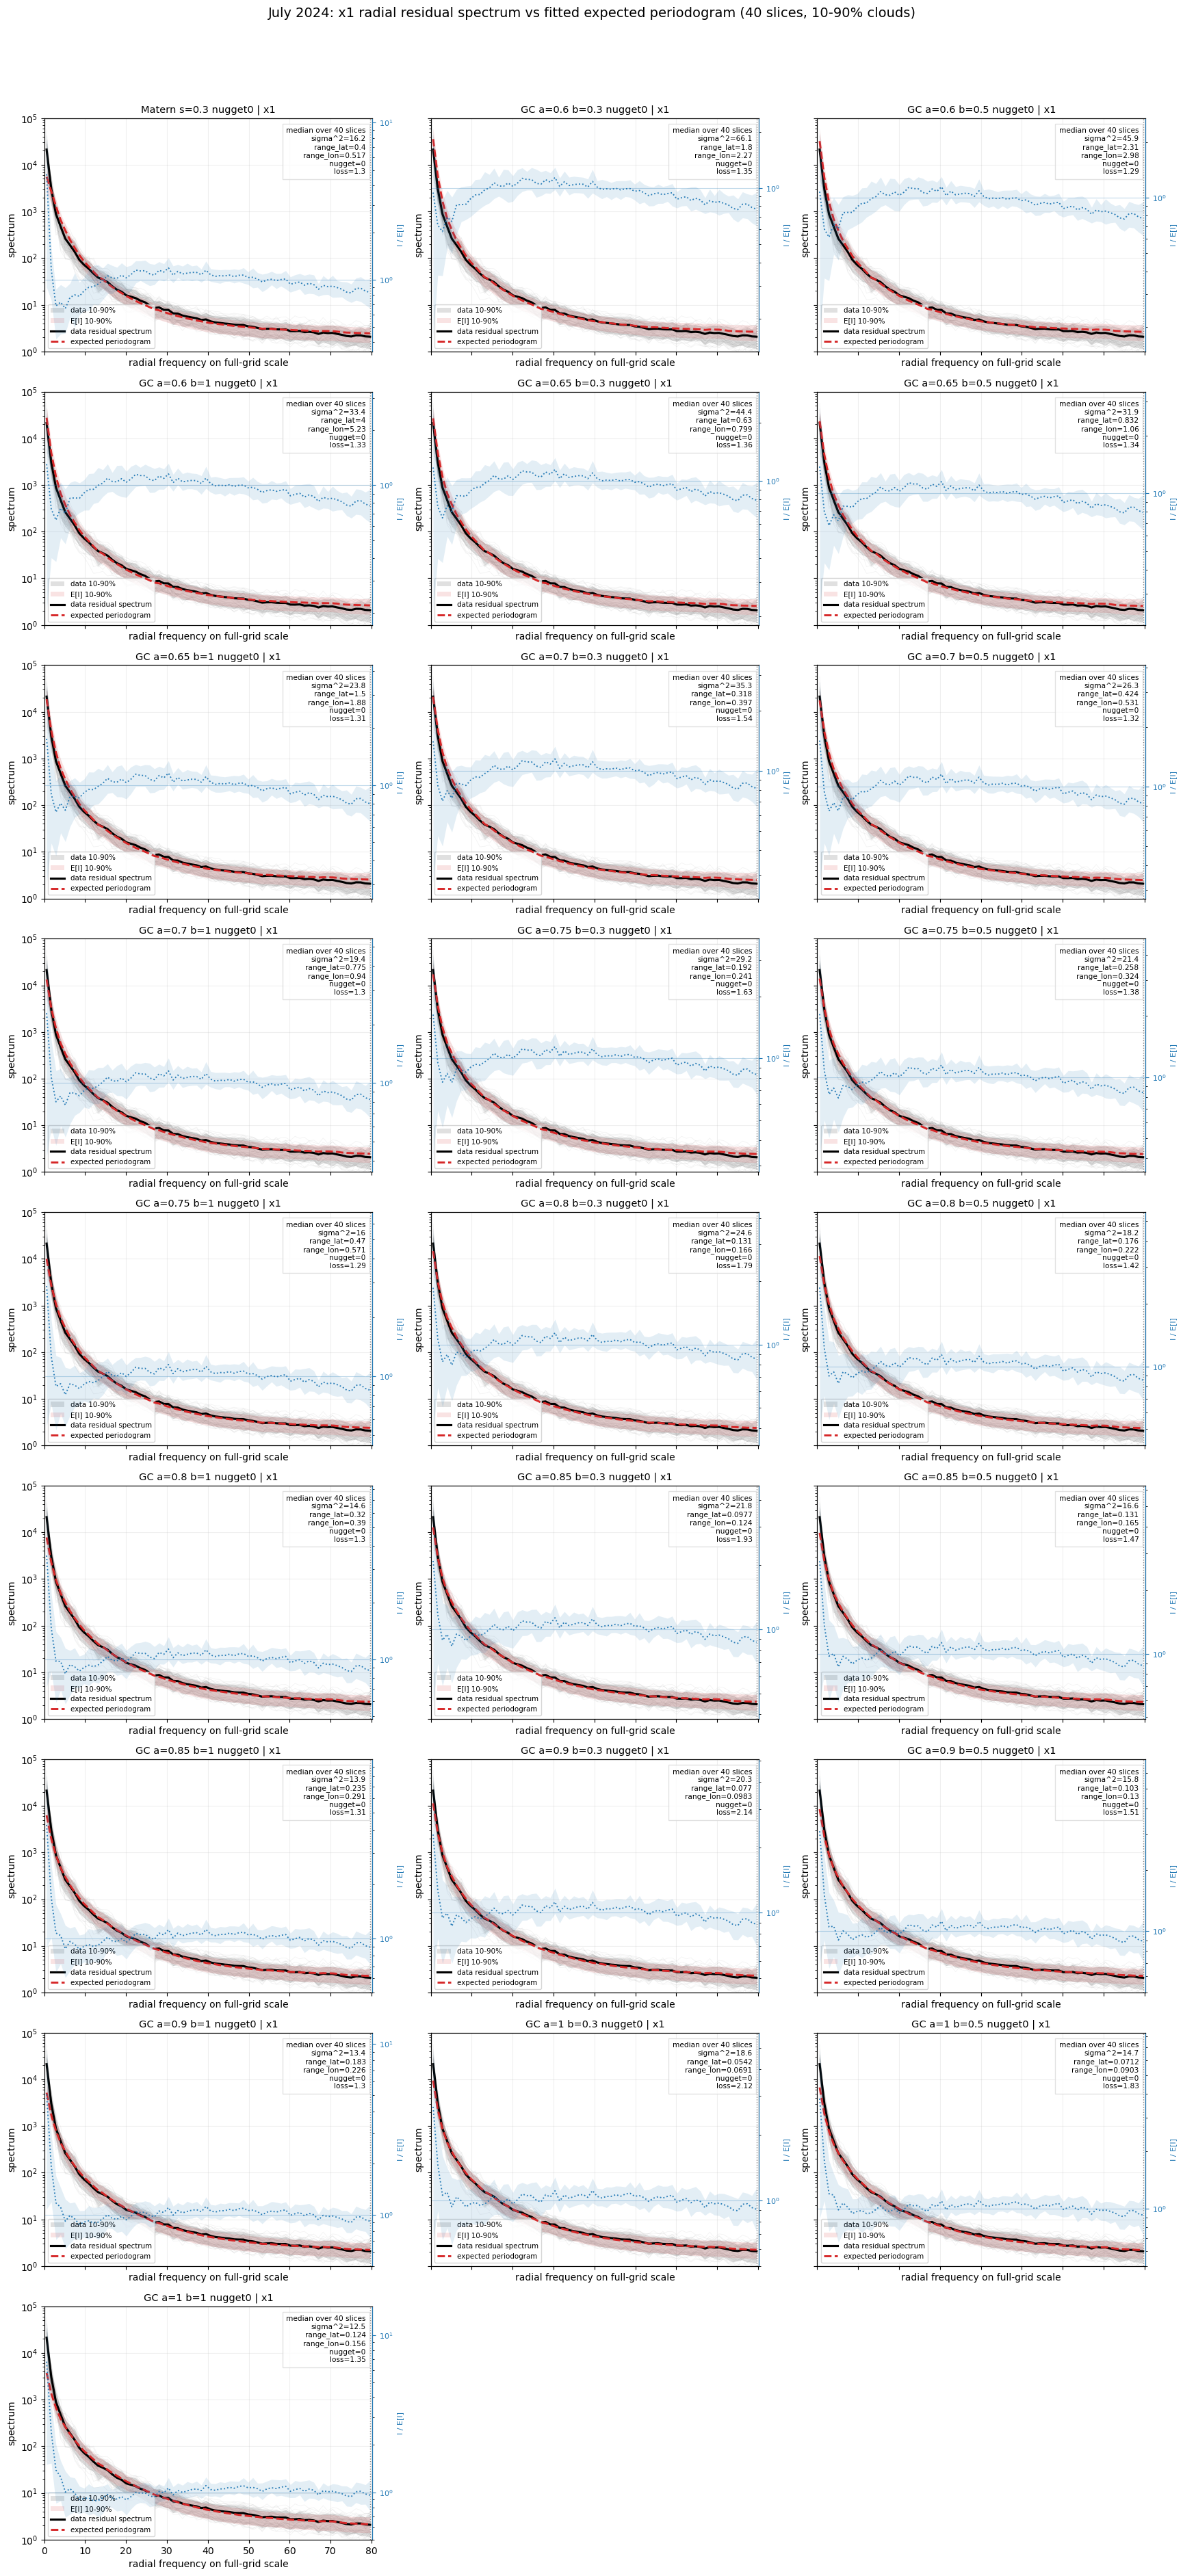

In [10]:
AVG_SPEC_BY_YEAR = {}
if RUN_PLOTS:
    for year in YEAR_CONFIGS:
        ctx = get_year_context(year)
        _, k_max_full, _ = spectral_grid_constants(ctx)
        variants = VARIANTS_BY_YEAR[year]
        spectral_df = SPECTRAL_DF_BY_YEAR.get(year)
        if spectral_df is None or spectral_df.empty:
            spectral_df = pd.read_csv(OUT_DIR / f'{year_prefix(year)}_radial_spectrum.csv')
        fit_df = FIT_DF_BY_YEAR.get(year)
        if fit_df is None or fit_df.empty:
            fit_df = pd.read_csv(OUT_DIR / f'{year_prefix(year)}_full.csv')

        def q10(x):
            x = pd.to_numeric(x, errors='coerce').replace([np.inf, -np.inf], np.nan).dropna()
            return float(np.nanquantile(x, 0.10)) if len(x) else np.nan

        def q90(x):
            x = pd.to_numeric(x, errors='coerce').replace([np.inf, -np.inf], np.nan).dropna()
            return float(np.nanquantile(x, 0.90)) if len(x) else np.nan

        plot_spec = spectral_df.replace([np.inf, -np.inf], np.nan).copy()
        plot_spec['ratio_I_over_EI'] = plot_spec['data_spectrum'] / plot_spec['theory_spectrum_expected']

        avg_spec = (
            plot_spec
            .groupby(['year', 'variant', 'model_label', 'nugget_mode', 'k_bin'], observed=False)
            .agg(
                k_mid=('k_mid', 'mean'),
                data_spectrum=('data_spectrum', 'mean'),
                data_spectrum_p10=('data_spectrum', q10),
                data_spectrum_p90=('data_spectrum', q90),
                theory_spectrum_expected=('theory_spectrum_expected', 'mean'),
                theory_spectrum_expected_p10=('theory_spectrum_expected', q10),
                theory_spectrum_expected_p90=('theory_spectrum_expected', q90),
                ratio_I_over_EI=('ratio_I_over_EI', 'mean'),
                ratio_I_over_EI_p10=('ratio_I_over_EI', q10),
                ratio_I_over_EI_p90=('ratio_I_over_EI', q90),
                n_slices=('time_position', 'nunique'),
                data_k_max=('data_k_max', 'mean'),
            )
            .reset_index()
        )

        AVG_SPEC_BY_YEAR[year] = avg_spec
        avg_path = OUT_DIR / f'{year_prefix(year)}_radial_spectrum_avg_by_variant.csv'
        avg_spec.to_csv(avg_path, index=False)
        print('Saved average radial spectrum with variability bands:', avg_path)

        param_summary = (
            fit_df
            .groupby(['year', 'variant', 'model_label', 'nugget_mode'], observed=False)
            .agg(
                n_slices=('time_position', 'nunique'),
                sigmasq_median=('est_sigmasq', 'median'),
                range_lat_median=('est_range_lat', 'median'),
                range_lon_median=('est_range_lon', 'median'),
                nugget_median=('est_nugget', 'median'),
                loss_median=('loss', 'median'),
                loss_mean=('loss', 'mean'),
            )
            .reset_index()
        )
        param_summary_path = OUT_DIR / f'{year_prefix(year)}_plot_param_summary.csv'
        round_df(param_summary).to_csv(param_summary_path, index=False, float_format=f'%.{ROUND_DECIMALS}f')
        print('Saved plot parameter summary:', param_summary_path)
        display(round_df(param_summary))

        positive_vals = pd.concat([
            pd.to_numeric(avg_spec['data_spectrum_p10'], errors='coerce'),
            pd.to_numeric(avg_spec['data_spectrum_p90'], errors='coerce'),
            pd.to_numeric(avg_spec['theory_spectrum_expected_p10'], errors='coerce'),
            pd.to_numeric(avg_spec['theory_spectrum_expected_p90'], errors='coerce'),
        ], ignore_index=True).replace([np.inf, -np.inf], np.nan).dropna()
        positive_vals = positive_vals[positive_vals > 0]
        spectrum_ylim = (1e-1, 1e5) if positive_vals.empty else (
            10 ** np.floor(np.log10(float(positive_vals.min()))),
            10 ** np.ceil(np.log10(float(positive_vals.max()))),
        )
        print(f'{year} radial spectrum y-limits:', spectrum_ylim)

        variant_order = list(variants)
        n_cols = 3
        n_rows = int(np.ceil(len(variant_order) / n_cols))
        fig, axes = plt.subplots(
            n_rows,
            n_cols,
            figsize=(5.8 * n_cols, 4.2 * n_rows),
            sharex=True,
            sharey=True,
        )
        axes = np.asarray(axes).reshape(n_rows, n_cols)

        for ax, variant in zip(axes.ravel(), variant_order):
            label = variants[variant]['label']
            sub_avg = avg_spec[avg_spec['variant'] == variant].sort_values('k_mid')
            sub_all = plot_spec[plot_spec['variant'] == variant]
            psub = param_summary[param_summary['variant'] == variant]

            for _, hs in sub_all.groupby('time_position'):
                hs = hs.sort_values('k_mid')
                ax.plot(
                    hs['k_mid'],
                    hs['data_spectrum'],
                    color='0.68',
                    alpha=0.14,
                    linewidth=0.62,
                    zorder=1,
                )

            if not sub_avg.empty:
                x = pd.to_numeric(sub_avg['k_mid'], errors='coerce').to_numpy(dtype=float)

                data_lo = pd.to_numeric(sub_avg['data_spectrum_p10'], errors='coerce').to_numpy(dtype=float)
                data_hi = pd.to_numeric(sub_avg['data_spectrum_p90'], errors='coerce').to_numpy(dtype=float)
                exp_lo = pd.to_numeric(sub_avg['theory_spectrum_expected_p10'], errors='coerce').to_numpy(dtype=float)
                exp_hi = pd.to_numeric(sub_avg['theory_spectrum_expected_p90'], errors='coerce').to_numpy(dtype=float)

                data_ok = np.isfinite(x) & np.isfinite(data_lo) & np.isfinite(data_hi) & (data_lo > 0) & (data_hi > 0)
                exp_ok = np.isfinite(x) & np.isfinite(exp_lo) & np.isfinite(exp_hi) & (exp_lo > 0) & (exp_hi > 0)

                if data_ok.any():
                    ax.fill_between(
                        x[data_ok],
                        data_lo[data_ok],
                        data_hi[data_ok],
                        color='black',
                        alpha=0.12,
                        linewidth=0,
                        label='data 10-90%',
                        zorder=2,
                    )
                if exp_ok.any():
                    ax.fill_between(
                        x[exp_ok],
                        exp_lo[exp_ok],
                        exp_hi[exp_ok],
                        color='tab:red',
                        alpha=0.13,
                        linewidth=0,
                        label='E[I] 10-90%',
                        zorder=3,
                    )

            ax.plot(
                sub_avg['k_mid'],
                sub_avg['data_spectrum'],
                color='black',
                linewidth=2.25,
                label='data residual spectrum',
                zorder=5,
            )
            ax.plot(
                sub_avg['k_mid'],
                sub_avg['theory_spectrum_expected'],
                color='tab:red',
                linewidth=2.1,
                linestyle='--',
                label='expected periodogram',
                zorder=6,
            )

            if not sub_avg.empty:
                k_cut = float(sub_avg['data_k_max'].mean())
                ax.axvline(k_cut, color='0.45', linewidth=1.0, linestyle=':', alpha=0.85, zorder=2)

            ratio = sub_avg[
                ['k_mid', 'ratio_I_over_EI', 'ratio_I_over_EI_p10', 'ratio_I_over_EI_p90']
            ].replace([np.inf, -np.inf], np.nan).dropna()
            ratio = ratio[(ratio['k_mid'] > 0) & (ratio['ratio_I_over_EI'] > 0)]

            if not ratio.empty:
                ratio_ax = ax.twinx()

                rx = pd.to_numeric(ratio['k_mid'], errors='coerce').to_numpy(dtype=float)
                rlo = pd.to_numeric(ratio['ratio_I_over_EI_p10'], errors='coerce').to_numpy(dtype=float)
                rhi = pd.to_numeric(ratio['ratio_I_over_EI_p90'], errors='coerce').to_numpy(dtype=float)
                rok = np.isfinite(rx) & np.isfinite(rlo) & np.isfinite(rhi) & (rlo > 0) & (rhi > 0)

                if rok.any():
                    ratio_ax.fill_between(
                        rx[rok],
                        rlo[rok],
                        rhi[rok],
                        color='tab:blue',
                        alpha=0.12,
                        linewidth=0,
                        zorder=6,
                    )

                ratio_ax.plot(
                    ratio['k_mid'],
                    ratio['ratio_I_over_EI'],
                    color='tab:blue',
                    linewidth=1.35,
                    linestyle=':',
                    alpha=0.95,
                    label='I / E[I]',
                    zorder=7,
                )
                ratio_ax.axhline(1.0, color='tab:blue', linewidth=0.8, alpha=0.28)
                ratio_ax.set_yscale('log')

                vals = pd.concat([
                    pd.to_numeric(ratio['ratio_I_over_EI_p10'], errors='coerce'),
                    pd.to_numeric(ratio['ratio_I_over_EI_p90'], errors='coerce'),
                ]).replace([np.inf, -np.inf], np.nan).dropna().to_numpy(dtype=float)
                vals = vals[vals > 0]

                if len(vals):
                    lo = max(1e-3, min(0.5, float(np.nanmin(vals)) / 1.2))
                    hi = min(1e3, max(2.0, float(np.nanmax(vals)) * 1.2))
                    if np.isfinite(lo) and np.isfinite(hi) and lo < hi:
                        ratio_ax.set_ylim(lo, hi)

                ratio_ax.tick_params(axis='y', colors='tab:blue', labelsize=8)
                ratio_ax.spines['right'].set_color('tab:blue')
                ratio_ax.set_ylabel('I / E[I]', color='tab:blue', fontsize=8)
                ratio_ax.grid(False)

            ax.set_title(label + ' | x1', fontsize=10.5)
            ax.set_yscale('log')
            ax.set_ylim(*spectrum_ylim)
            ax.set_xlim(0, k_max_full)
            ax.grid(alpha=0.2)
            ax.set_xlabel('radial frequency on full-grid scale')
            ax.set_ylabel('spectrum')

            if not psub.empty:
                p = psub.iloc[0]
                param_text = (
                    f"median over {int(p.n_slices)} slices\n"
                    f"sigma^2={p.sigmasq_median:.3g}\n"
                    f"range_lat={p.range_lat_median:.3g}\n"
                    f"range_lon={p.range_lon_median:.3g}\n"
                    f"nugget={p.nugget_median:.3g}\n"
                    f"loss={p.loss_median:.5f}"
                )
                ax.text(
                    0.98,
                    0.96,
                    param_text,
                    transform=ax.transAxes,
                    ha='right',
                    va='top',
                    fontsize=7.6,
                    bbox=dict(facecolor='white', edgecolor='0.85', alpha=0.78),
                )

            handles, labels = ax.get_legend_handles_labels()
            if handles:
                ax.legend(handles, labels, fontsize=7.4, loc='lower left')

        for ax in axes.ravel()[len(variant_order):]:
            ax.axis('off')

        fig.suptitle(
            f'July {year}: x1 radial residual spectrum vs fitted expected periodogram '
            f'({len(ctx["selected_time_df"])} slices, 10-90% clouds)',
            y=0.995,
            fontsize=14,
        )
        fig.tight_layout(rect=[0, 0, 1, 0.97])

        plot_path = OUT_DIR / f'{year_prefix(year)}_radial_expected_periodogram_x1_avg.png'
        fig.savefig(plot_path, dpi=220, bbox_inches='tight')
        print('Saved x1 average radial diagnostic plot:', plot_path)
        plt.show()

In [11]:
if RUN_TABLES:
    for year in YEAR_CONFIGS:
        variants = VARIANTS_BY_YEAR[year]
        avg_spec = AVG_SPEC_BY_YEAR.get(year)
        if avg_spec is None or avg_spec.empty:
            avg_spec = pd.read_csv(OUT_DIR / f'{year_prefix(year)}_radial_spectrum_avg_by_variant.csv')
        avg_spec = avg_spec.replace([np.inf, -np.inf], np.nan).copy()
        variant_order = [v for v in variants if v in set(avg_spec['variant'].astype(str))]
        label_by_variant = dict(avg_spec.drop_duplicates('variant')[['variant', 'model_label']].values)
        ordered_model_labels = [label_by_variant.get(v, v) for v in variant_order if label_by_variant.get(v, v) in set(avg_spec['model_label'])]

        ratio_pivot_all = (
            avg_spec
            .pivot_table(index=['k_bin', 'k_mid'], columns='model_label', values='ratio_I_over_EI', aggfunc='first')
            .reset_index()
            .sort_values(['k_bin', 'k_mid'])
        )
        ratio_pivot_all = ratio_pivot_all[['k_bin', 'k_mid'] + ordered_model_labels]
        ratio_pivot_all_path = OUT_DIR / f'{year_prefix(year)}_all_frequency_ratio_pivot.csv'
        round_df(ratio_pivot_all).to_csv(ratio_pivot_all_path, index=False, float_format=f'%.{ROUND_DECIMALS}f')
        print('Saved all-frequency ratio pivot:', ratio_pivot_all_path)

        all_bins = sorted(pd.to_numeric(ratio_pivot_all['k_bin'], errors='coerce').dropna().astype(int).unique())
        selected_bins = sorted(set([b for b in all_bins if b < 5] + [b for b in all_bins if b % 5 == 0] + [max(all_bins)]))
        ratio_pivot_selected = ratio_pivot_all[ratio_pivot_all['k_bin'].isin(selected_bins)].copy()
        ratio_pivot_selected_path = OUT_DIR / f'{year_prefix(year)}_selected_frequency_ratio_pivot.csv'
        round_df(ratio_pivot_selected).to_csv(ratio_pivot_selected_path, index=False, float_format=f'%.{ROUND_DECIMALS}f')
        print('Saved selected-frequency ratio pivot:', ratio_pivot_selected_path)
        display(round_df(ratio_pivot_selected))

        band_defs = [
            ('ultra_low', 0, 4),
            ('low_mid', 5, 14),
            ('mid', 15, 29),
            ('high', 30, 49),
            ('very_high', 50, max(all_bins)),
        ]
        band_rows = []
        for band_name, lo, hi in band_defs:
            sub_band = avg_spec[
                (pd.to_numeric(avg_spec['k_bin'], errors='coerce') >= lo)
                & (pd.to_numeric(avg_spec['k_bin'], errors='coerce') <= hi)
            ].copy()
            if sub_band.empty:
                continue
            for variant in variant_order:
                sv = sub_band[sub_band['variant'].astype(str) == str(variant)].copy()
                if sv.empty:
                    continue
                vals = pd.to_numeric(sv['ratio_I_over_EI'], errors='coerce').replace([np.inf, -np.inf], np.nan).dropna()
                band_rows.append({
                    'frequency_band': band_name,
                    'k_bin_start': int(lo),
                    'k_bin_end': int(hi),
                    'k_mid_min': float(pd.to_numeric(sv['k_mid'], errors='coerce').min()),
                    'k_mid_max': float(pd.to_numeric(sv['k_mid'], errors='coerce').max()),
                    'variant': variant,
                    'model_label': label_by_variant.get(variant, variant),
                    'n_bins': int(vals.shape[0]),
                    'ratio_mean': float(vals.mean()) if len(vals) else np.nan,
                    'ratio_median': float(vals.median()) if len(vals) else np.nan,
                    'ratio_min': float(vals.min()) if len(vals) else np.nan,
                    'ratio_max': float(vals.max()) if len(vals) else np.nan,
                })

        band_ratio_summary = pd.DataFrame(band_rows)
        band_ratio_summary_path = OUT_DIR / f'{year_prefix(year)}_frequency_band_ratio_summary.csv'
        round_df(band_ratio_summary).to_csv(band_ratio_summary_path, index=False, float_format=f'%.{ROUND_DECIMALS}f')
        print('Saved frequency-band ratio summary:', band_ratio_summary_path)

        band_order = {name: i for i, (name, _, _) in enumerate(band_defs)}
        for stat in ['mean', 'median']:
            value_col = f'ratio_{stat}'
            pivot = (
                band_ratio_summary
                .pivot_table(index=['frequency_band', 'k_mid_min', 'k_mid_max'], columns='model_label', values=value_col, aggfunc='first')
                .reset_index()
            )
            pivot['_order'] = pivot['frequency_band'].map(band_order)
            pivot = pivot.sort_values('_order').drop(columns=['_order'])
            pivot = pivot[['frequency_band', 'k_mid_min', 'k_mid_max'] + ordered_model_labels]
            pivot_path = OUT_DIR / f'{year_prefix(year)}_frequency_band_ratio_{stat}_pivot.csv'
            round_df(pivot).to_csv(pivot_path, index=False, float_format=f'%.{ROUND_DECIMALS}f')
            print(f'Saved frequency-band {stat} ratio pivot:', pivot_path)
            display(round_df(pivot))


Saved all-frequency ratio pivot: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/real_pure_space_spectral_x1_2024_gc_alpha_beta_grid_refine_nugget0_clusterb2_061426_2024_all_frequency_ratio_pivot.csv
Saved selected-frequency ratio pivot: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/real_pure_space_spectral_x1_2024_gc_alpha_beta_grid_refine_nugget0_clusterb2_061426_2024_selected_frequency_ratio_pivot.csv


model_label,k_bin,k_mid,Matern s=0.3 nugget0,GC a=0.6 b=0.3 nugget0,GC a=0.6 b=0.5 nugget0,GC a=0.6 b=1 nugget0,GC a=0.65 b=0.3 nugget0,GC a=0.65 b=0.5 nugget0,GC a=0.65 b=1 nugget0,GC a=0.7 b=0.3 nugget0,GC a=0.7 b=0.5 nugget0,GC a=0.7 b=1 nugget0,GC a=0.75 b=0.3 nugget0,GC a=0.75 b=0.5 nugget0,GC a=0.75 b=1 nugget0,GC a=0.8 b=0.3 nugget0,GC a=0.8 b=0.5 nugget0,GC a=0.8 b=1 nugget0,GC a=0.85 b=0.3 nugget0,GC a=0.85 b=0.5 nugget0,GC a=0.85 b=1 nugget0,GC a=0.9 b=0.3 nugget0,GC a=0.9 b=0.5 nugget0,GC a=0.9 b=1 nugget0,GC a=1 b=0.3 nugget0,GC a=1 b=0.5 nugget0,GC a=1 b=1 nugget0
0,0,0.5729,4.7017,0.9451,1.0779,1.3050,1.1714,1.3795,1.7564,1.4043,1.7051,2.2853,1.6362,2.0457,2.8862,1.8631,2.3950,3.5541,2.0825,2.7474,4.2831,2.2925,3.0983,5.0669,2.6802,3.7814,6.7697
1,1,1.7187,1.1577,0.6322,0.6771,0.7413,0.7356,0.8020,0.8972,0.8443,0.9365,1.0710,0.9535,1.0761,1.2604,1.0611,1.2188,1.4649,1.1661,1.3629,1.6831,1.2676,1.5068,1.9144,1.4578,1.7894,2.4105
2,2,2.8645,0.6817,0.5847,0.6112,0.6450,0.6435,0.6790,0.7212,0.7049,0.7503,0.8017,0.7665,0.8236,0.8867,0.8275,0.8982,0.9767,0.8872,0.9735,1.0717,0.9453,1.0488,1.1716,1.0550,1.1970,1.3844
3,3,4.0103,0.7204,0.6976,0.7203,0.7491,0.7447,0.7728,0.8037,0.7944,0.8275,0.8586,0.8448,0.8837,0.9152,0.8952,0.9414,0.9747,0.9453,1.0001,1.0379,0.9947,1.0595,1.1050,1.0896,1.1784,1.2500
4,4,5.1561,0.6562,0.6620,0.6802,0.7026,0.6951,0.7164,0.7381,0.7292,0.7528,0.7712,0.7636,0.7896,0.8041,0.7981,0.8274,0.8386,0.8327,0.8662,0.8754,0.8670,0.9057,0.9151,0.9338,0.9857,1.0025
5,5,6.3019,0.7713,0.8123,0.8296,0.8496,0.8371,0.8561,0.8731,0.8637,0.8834,0.8941,0.8913,0.9115,0.9148,0.9196,0.9411,0.9371,0.9487,0.9722,0.9620,0.9781,1.0045,0.9900,1.0366,1.0716,1.0548
10,10,12.0309,0.9044,0.9232,0.9356,0.9502,0.9257,0.9376,0.9476,0.9272,0.9368,0.9387,0.9282,0.9348,0.9265,0.9299,0.9333,0.9141,0.9327,0.9332,0.9028,0.9368,0.9347,0.8938,0.9484,0.9428,0.8835
15,15,17.7599,1.0207,1.0212,1.0313,1.0432,1.0195,1.0286,1.0359,1.0145,1.0210,1.0210,1.0076,1.0108,1.0016,1.0004,0.9998,0.9805,0.9938,0.9894,0.9595,0.9882,0.9802,0.9397,0.9804,0.9661,0.9054
20,20,23.4890,1.1388,1.1111,1.1198,1.1304,1.1111,1.1189,1.1263,1.1060,1.1117,1.1134,1.0976,1.1005,1.0950,1.0879,1.0874,1.0738,1.0778,1.0737,1.0512,1.0681,1.0604,1.0286,1.0512,1.0364,0.9856
25,25,29.2180,1.1202,1.0748,1.0815,1.0902,1.0796,1.0861,1.0930,1.0792,1.0843,1.0878,1.0748,1.0781,1.0772,1.0682,1.0692,1.0630,1.0603,1.0588,1.0466,1.0521,1.0477,1.0290,1.0358,1.0257,0.9926


Saved frequency-band ratio summary: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/real_pure_space_spectral_x1_2024_gc_alpha_beta_grid_refine_nugget0_clusterb2_061426_2024_frequency_band_ratio_summary.csv
Saved frequency-band mean ratio pivot: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/real_pure_space_spectral_x1_2024_gc_alpha_beta_grid_refine_nugget0_clusterb2_061426_2024_frequency_band_ratio_mean_pivot.csv


model_label,frequency_band,k_mid_min,k_mid_max,Matern s=0.3 nugget0,GC a=0.6 b=0.3 nugget0,GC a=0.6 b=0.5 nugget0,GC a=0.6 b=1 nugget0,GC a=0.65 b=0.3 nugget0,GC a=0.65 b=0.5 nugget0,GC a=0.65 b=1 nugget0,GC a=0.7 b=0.3 nugget0,GC a=0.7 b=0.5 nugget0,GC a=0.7 b=1 nugget0,GC a=0.75 b=0.3 nugget0,GC a=0.75 b=0.5 nugget0,GC a=0.75 b=1 nugget0,GC a=0.8 b=0.3 nugget0,GC a=0.8 b=0.5 nugget0,GC a=0.8 b=1 nugget0,GC a=0.85 b=0.3 nugget0,GC a=0.85 b=0.5 nugget0,GC a=0.85 b=1 nugget0,GC a=0.9 b=0.3 nugget0,GC a=0.9 b=0.5 nugget0,GC a=0.9 b=1 nugget0,GC a=1 b=0.3 nugget0,GC a=1 b=0.5 nugget0,GC a=1 b=1 nugget0
3,ultra_low,0.5729,5.1561,1.5835,0.7043,0.7534,0.8286,0.7981,0.8699,0.9833,0.8954,0.9944,1.1576,0.9929,1.1237,1.3505,1.0890,1.2562,1.5618,1.1828,1.3900,1.7902,1.2734,1.5238,2.0346,1.4433,1.7864,2.5634
1,low_mid,6.3019,16.6141,0.9028,0.9236,0.9371,0.9529,0.9311,0.9444,0.9558,0.9377,0.9492,0.9527,0.9437,0.9529,0.9467,0.9503,0.9571,0.9404,0.9578,0.9625,0.9356,0.9664,0.9694,0.9329,0.9860,0.9877,0.9353
2,mid,17.7599,33.8012,1.1031,1.0716,1.0792,1.0887,1.0737,1.0807,1.0876,1.0709,1.0763,1.0785,1.0650,1.0680,1.0643,1.0574,1.0576,1.0471,1.0493,1.0465,1.0285,1.0412,1.0353,1.0094,1.0264,1.0144,0.9722
0,high,34.9470,56.7172,1.0554,0.9869,0.9903,0.9955,1.0053,1.0093,1.0154,1.0189,1.0233,1.0300,1.0286,1.0333,1.0405,1.0354,1.0402,1.0478,1.0399,1.0448,1.0526,1.0428,1.0475,1.0553,1.0449,1.0489,1.0557
4,very_high,57.8630,79.6333,0.9078,0.8434,0.8445,0.8469,0.8670,0.8690,0.8732,0.8875,0.8907,0.8972,0.9055,0.9099,0.9194,0.9212,0.9271,0.9399,0.9351,0.9426,0.9591,0.9475,0.9566,0.9770,0.9681,0.9805,1.0094


Saved frequency-band median ratio pivot: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/log/real_pure_space_spectral_x1_2024_gc_alpha_beta_grid_refine_nugget0_clusterb2_061426_2024_frequency_band_ratio_median_pivot.csv


model_label,frequency_band,k_mid_min,k_mid_max,Matern s=0.3 nugget0,GC a=0.6 b=0.3 nugget0,GC a=0.6 b=0.5 nugget0,GC a=0.6 b=1 nugget0,GC a=0.65 b=0.3 nugget0,GC a=0.65 b=0.5 nugget0,GC a=0.65 b=1 nugget0,GC a=0.7 b=0.3 nugget0,GC a=0.7 b=0.5 nugget0,GC a=0.7 b=1 nugget0,GC a=0.75 b=0.3 nugget0,GC a=0.75 b=0.5 nugget0,GC a=0.75 b=1 nugget0,GC a=0.8 b=0.3 nugget0,GC a=0.8 b=0.5 nugget0,GC a=0.8 b=1 nugget0,GC a=0.85 b=0.3 nugget0,GC a=0.85 b=0.5 nugget0,GC a=0.85 b=1 nugget0,GC a=0.9 b=0.3 nugget0,GC a=0.9 b=0.5 nugget0,GC a=0.9 b=1 nugget0,GC a=1 b=0.3 nugget0,GC a=1 b=0.5 nugget0,GC a=1 b=1 nugget0
3,ultra_low,0.5729,5.1561,0.7204,0.6620,0.6802,0.7413,0.7356,0.7728,0.8037,0.7944,0.8275,0.8586,0.8448,0.8837,0.9152,0.8952,0.9414,0.9767,0.9453,1.0001,1.0717,0.9947,1.0595,1.1716,1.0896,1.1970,1.3844
1,low_mid,6.3019,16.6141,0.9004,0.9206,0.9338,0.9494,0.9257,0.9385,0.9493,0.9297,0.9402,0.9426,0.9330,0.9406,0.9327,0.9369,0.9455,0.9323,0.9500,0.9534,0.9256,0.9580,0.9636,0.9319,0.9866,0.9794,0.9190
2,mid,17.7599,33.8012,1.0910,1.0641,1.0742,1.0862,1.0620,1.0710,1.0787,1.0560,1.0625,1.0631,1.0483,1.0510,1.0524,1.0433,1.0459,1.0454,1.0390,1.0399,1.0357,1.0337,1.0327,1.0241,1.0217,1.0164,0.9856
0,high,34.9470,56.7172,1.0601,0.9874,0.9913,0.9972,1.0065,1.0112,1.0181,1.0202,1.0253,1.0326,1.0297,1.0349,1.0425,1.0360,1.0412,1.0484,1.0397,1.0439,1.0527,1.0420,1.0468,1.0541,1.0425,1.0471,1.0534
4,very_high,57.8630,79.6333,0.9075,0.8412,0.8427,0.8456,0.8653,0.8678,0.8725,0.8864,0.8899,0.8970,0.9047,0.9096,0.9196,0.9208,0.9272,0.9404,0.9349,0.9429,0.9598,0.9474,0.9570,0.9779,0.9683,0.9821,1.0134
